# **Spread Z-Score Strategy**

### Core Idea of the Strategy

Pairs trading assumes that two related assets maintain a **stable long-term relationship**.

When the spread temporarily deviates from its typical level, it is expected to **revert back toward equilibrium**.

The strategy therefore:

1. Detects **abnormal spread deviations**
2. Takes positions betting on **mean reversion**


### Spread Normalization Using Z-Score

To detect abnormal deviations, the spread is standardized using a **rolling Z-score**.

$$ Z_t = \frac{Spread_t - \mu_t}{\sigma_t} $$

Where

* $ \mu_t $ = rolling mean of the spread
* $ \sigma_t $ = rolling standard deviation

The Z-score indicates how far the spread is from its normal level.

| Z-score | Interpretation        |
| ------- | --------------------- |
| 0       | spread at equilibrium |
| ±1      | moderate deviation    |
| ±2      | strong deviation      |
| ±3      | extreme deviation     |

So **Z-Score** is a representation of implied volatility.

**Implied Volatility (IV)**: Implied volatility is the volatility level that the market expects for an asset in the future, inferred from the price of an option.

## `Z-Score Trading Strategy`

The Z-score strategy uses **entry and exit thresholds** to trade spread deviations.

### Entry Condition
Enter a trade when
$$ |Z| \ge 1.0 $$
This indicates the spread has deviated significantly from its average.

| Z-score condition | Position     |
| ----------------- | ------------ |
| (Z > 1)           | Short spread |
| (Z < -1)          | Long spread  |


Interpretation:
* If the spread is **too large**, expect it to **fall**
* If the spread is **too small**, expect it to **rise**

### Exit Condition

Close the position when
$$ |Z| \le 0.25 $$

This indicates the spread has **returned close to equilibrium**.

In [35]:
import os
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from datetime import datetime
from typing import Tuple, Dict

data_dir = 'data'


### Data Characteristics

The dataset contains time-indexed observations of two related financial series.
From these values a **spread** is constructed.
The dataset also contains:

| Variable | Meaning                           |
| -------- | --------------------------------- |
| time     | timestamp of observation          |
| spread   | difference between the two assets |
| TTE      | time to expiry of the option      |


### Handling Irregular Time Series

Financial datasets often contain **missing minutes**, **irregular observations** and **market breaks**. To avoid these distortions, In this project, the strategy uses **time-based rolling windows** instead of fixed observation counts. This ensures statistical measures reflect **actual time intervals**, not just row counts.

In [36]:
data_path = os.path.join(data_dir, "processed_data.parquet")
df = pd.read_parquet(data_path)
df.head()

,banknifty,nifty,tte
time,,,
2021-01-01 09:15:00,0.286058,0.199729,27
2021-01-01 09:16:00,0.285381,0.200433,27
2021-01-01 09:17:00,0.284233,0.200004,27
2021-01-01 09:18:00,0.286104,0.199860,27
2021-01-01 09:19:00,0.285539,0.198951,27


In [37]:
# Spread and TTE scaling
df["spread"] = df["banknifty"] - df["nifty"]
df["tte_pow"] = np.power(df["tte"].astype(float), 0.7)

# Minute-to-minute change in spread
df["dspread"] = df["spread"].diff()

## **Baseline Startegy**

$$ Position_t = sign(Spread_t) $$

Meaning:
* Positive spread → short spread
* Negative spread → long spread

This strategy always maintains a position based only on the **spread direction**. It does **not consider statistical deviations**.


In [38]:
# Rule: position = sign(spread). Persistent (±1 or 0 if spread == 0)

def baseline_position(s: pd.Series) -> pd.Series:
    pos = s.apply(lambda x: 0.0 if pd.isna(x) or x == 0 else (1.0 if x > 0 else -1.0))
    return pos

df["pos_baseline"] = baseline_position(df["spread"])

# PnL per bar
df["pnl_baseline"] = df["pos_baseline"].shift(1) * df["dspread"] * df["tte_pow"]

# Z-Score strategy with 0 latency

In [39]:
# Time-based rolling window to handle gaps

ROLL_WINDOW = "90min"
MIN_PERIODS = 30  # need at least 30 points in the rolling window

roll_mean = df["spread"].rolling(ROLL_WINDOW, min_periods=MIN_PERIODS).mean()
roll_std = df["spread"].rolling(ROLL_WINDOW, min_periods=MIN_PERIODS).std(ddof=0)
df["z"] = (df["spread"] - roll_mean) / roll_std

Z_ENTER = 1.0
Z_EXIT = 0.25

In [40]:
def generate_zscore_positions(zscore, entry_threshold, exit_threshold):
    """
    1. Enter SHORT spread (-1) when zscore >= entry_threshold
    2. Enter LONG spread (+1) when zscore <= -entry_threshold
    3. Exit position when |zscore| <= exit_threshold
    4. Otherwise maintain previous position (hysteresis)
    """

    positions = np.zeros(len(zscore))
    current_position = 0.0

    for i, z in enumerate(zscore):

        if pd.isna(z):
            positions[i] = current_position
            continue

        if z >= entry_threshold:
            current_position = -1.0

        elif z <= -entry_threshold:
            current_position = 1.0

        elif abs(z) <= exit_threshold:
            current_position = 0.0

        positions[i] = current_position

    return pd.Series(positions, index=zscore.index)

df["pos_z"] = generate_zscore_positions(
    df["z"],
    entry_threshold=Z_ENTER,
    exit_threshold=Z_EXIT
)

df["pnl_z"] = (
    df["pos_z"].shift(1)
    * df["dspread"]
    * df["tte_pow"]
)

## **Profit and Loss Calculation**

The strategy calculates incremental profit using:

$$ dPnL_t = Position_{t-1} \times (Spread_t - Spread_{t-1}) \times (TTE_t)^{0.7} $$

Where:

| Term                      | Meaning                         |
| ------------------------- | ------------------------------- |
| $Position_{t-1}$          | position held during the period |
| $Spread_t - Spread_{t-1}$ | spread change                   |
| $TTE_t^{0.7}$             | time-to-expiry adjustment       |



The factor $ (TTE)^{0.7} $ scales profits depending on **option maturity**.

Options with longer time to expiry typically have:

* higher volatility exposure
* stronger spread sensitivity

The exponent **0.7** moderates this effect.

## Profit and Loss (PnL)

**Profit and Loss (PnL)** measures the **total profit generated by the trading strategy over the entire trading period**.

It is computed by summing all incremental profits:

$$ PnL = \sum_{t} dPnL_t $$

where $ dPnL_t $ represents the profit generated during each time step.

A **positive PnL** indicates that the strategy is profitable, while a **negative PnL** indicates losses.

In this project, PnL is calculated from changes in the **spread between the two assets**, adjusted by the **position held and time-to-expiry scaling**.


## Sharpe Ratio

The **Sharpe Ratio** measures the **risk-adjusted performance** of a strategy.

It compares the **average return earned by the strategy** to the **volatility of those returns**.

$$ Sharpe = \frac{\mu}{\sigma} \times \sqrt{252} $$

| Term           | Meaning                                       |
| -------------- | --------------------------------------------- |
| $ \mu $        | average daily return                          |
| $ \sigma $     | standard deviation of daily returns           |
| $ \sqrt{252} $ | annualization factor (trading days in a year) |

Interpretation:

| Sharpe Ratio | Meaning                        |
| ------------ | ------------------------------ |
| < 1          | weak risk-adjusted performance |
| 1–2          | good                           |
| 2–3          | very good                      |
| > 3          | excellent                      |

A **higher Sharpe ratio indicates better return per unit of risk**.


## Maximum Drawdown

**Maximum Drawdown (Max DD)** measures the **largest peak-to-trough decline in the equity curve** during the trading period.

It captures the **worst loss experienced from a previous high point**.

$$ MaxDrawdown = \min(E_t - \max_{s \le t} E_s) $$

Where:

| Term                 | Meaning                  |
| -------------------- | ------------------------ |
| $E_t$                | equity value at time (t) |
| $\max_{s \le t} E_s$ | historical peak equity   |

Interpretation:

* A **large drawdown** indicates high downside risk.
* A **smaller drawdown** suggests a more stable strategy.

In [41]:
# PnL Calculation
def compute_incremental_pnl( position, spread, tte, tte_power: float = 0.7):
    spread_change = spread.diff()
    position_lag = position.shift(1)

    tte_adjustment = tte ** tte_power
    pnl = position_lag * spread_change * tte_adjustment
    return pnl

# Performance Metrics
def equity_and_drawdown(pnl):
    # Compute cumulative equity curve and maximum drawdown.
    equity = pnl.fillna(0).cumsum()
    running_peak = equity.cummax()

    drawdown = equity - running_peak
    max_drawdown = drawdown.min()

    return equity, float(max_drawdown)

def sharpe_ratio_daily(pnl):
    """
    Compute annualized Sharpe ratio.

    Steps:
    1. Aggregate minute PnL to daily PnL
    2. Compute mean and standard deviation
    3. Annualize using sqrt(252)
    """

    pnl = pnl.dropna()
    if pnl.empty:
        return float("nan")

    daily_pnl = pnl.groupby(pnl.index.date).sum()

    mean_daily = daily_pnl.mean()
    std_daily = daily_pnl.std(ddof=0)

    if std_daily == 0 or np.isnan(std_daily):
        return float("nan")

    sharpe = (mean_daily / std_daily) * math.sqrt(252)

    return float(sharpe)

def summarize_strategy(pnl, label):
    equity, max_dd = equity_and_drawdown(pnl)

    total_pnl = float(pnl.fillna(0).sum())
    abs_pnl = float(pnl.fillna(0).abs().sum())

    sharpe = sharpe_ratio_daily(pnl)

    # Approximate number of trades
    trade_indicator = (pnl.fillna(0) != 0).astype(int)
    trades = int(trade_indicator.diff().abs().clip(upper=1).sum() // 2)

    return {
        "strategy": label,
        "total_PnL": total_pnl,
        "gross_PnL": abs_pnl,
        "sharpe_annualized": sharpe,
        "max_drawdown": max_dd,
        "observations": int(pnl.shape[0]),
        "approx_trades": trades,
    }

In [42]:
metrics = pd.DataFrame([
    summarize_strategy(df["pnl_baseline"], "Baseline Spread Strategy"),
    summarize_strategy(df["pnl_z"], "Z-Score Mean Reversion Strategy"),
])

metrics

,strategy,total_PnL,gross_PnL,sharpe_annualized,max_drawdown,observations,approx_trades
0,Baseline Spread Strategy,24.225911,1268.587827,1.734532,-3.757137,687013,310
1,Z-Score Mean Reversion Strategy,297.948518,924.661601,4.346117,-0.975061,687013,5413


In [43]:
# Equity Curve Computation

# cumulative equity curves for each strategy
equity_baseline, _ = equity_and_drawdown(df["pnl_baseline"])
equity_zscore, _ = equity_and_drawdown(df["pnl_z"])

equity_curves = pd.DataFrame({
    "Baseline Strategy": equity_baseline,
    "Z-Score Strategy": equity_zscore
})

equity_curves

,Baseline Strategy,Z-Score Strategy
time,,
2021-01-01 09:15:00,0.000000,0.000000
2021-01-01 09:16:00,-0.013867,0.000000
2021-01-01 09:17:00,-0.021095,0.000000
2021-01-01 09:18:00,-0.000859,0.000000
2021-01-01 09:19:00,0.002602,0.000000
...,...,...
2022-06-30 15:26:00,24.227106,297.909378
2022-06-30 15:27:00,24.210346,297.909378
2022-06-30 15:28:00,24.220697,297.919729


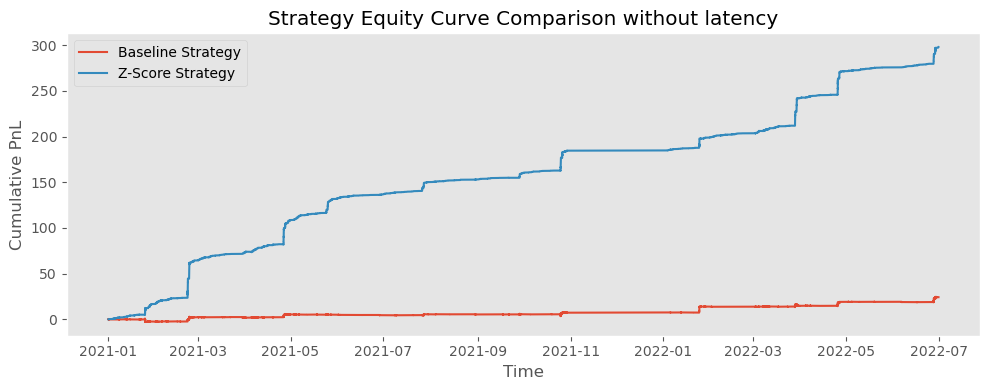

In [44]:
# Equity Curve Comparison

plt.figure(figsize=(10, 4))

plt.plot(equity_curves.index, equity_curves["Baseline Strategy"], label="Baseline Strategy")
plt.plot(equity_curves.index, equity_curves["Z-Score Strategy"], label="Z-Score Strategy")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.title("Strategy Equity Curve Comparison without latency")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

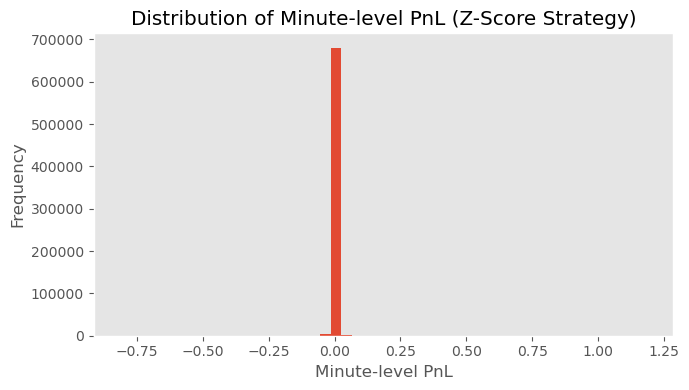

In [45]:
# Distribution of Minute-level PnL (Z-Score Strategy)

plt.figure(figsize=(7, 4))

df["pnl_z"].dropna().hist(bins=50)

plt.xlabel("Minute-level PnL")
plt.ylabel("Frequency")
plt.title("Distribution of Minute-level PnL (Z-Score Strategy)")

plt.grid()
plt.tight_layout()
plt.show()

## **Z-Score strategy with 1 minute latency**

In [46]:
# Introduce execution latency: Signal generated at time t is executed at time t+1
df["pos_z_latency"] = df["pos_z"].shift(1)

# PnL uses the executed position with another lag (position held during interval)
df["pnl_z_latency"] = (
    df["pos_z_latency"].shift(1)
    * df["dspread"]
    * df["tte_pow"]
)

metrics = pd.DataFrame([
    summarize_strategy(df["pnl_baseline"], "Baseline Strategy"),
    summarize_strategy(df["pnl_z_latency"], "Z-Score Strategy (1m Latency)")
])

metrics

,strategy,total_PnL,gross_PnL,sharpe_annualized,max_drawdown,observations,approx_trades
0,Baseline Strategy,24.225911,1268.587827,1.734532,-3.757137,687013,310
1,Z-Score Strategy (1m Latency),114.757662,889.895484,5.074669,-2.854294,687013,5400


In [47]:
# Equity Curve Comparison 

equity_baseline, _ = equity_and_drawdown(df["pnl_baseline"])
equity_z_latency, _ = equity_and_drawdown(df["pnl_z_latency"])

equity_curves = pd.DataFrame({
    "Baseline Strategy": equity_baseline,
    "Z-Score Strategy (1m Latency)": equity_z_latency
})

equity_curves

,Baseline Strategy,Z-Score Strategy (1m Latency)
time,,
2021-01-01 09:15:00,0.000000,0.000000
2021-01-01 09:16:00,-0.013867,0.000000
2021-01-01 09:17:00,-0.021095,0.000000
2021-01-01 09:18:00,-0.000859,0.000000
2021-01-01 09:19:00,0.002602,0.000000
...,...,...
2022-06-30 15:26:00,24.227106,114.752448
2022-06-30 15:27:00,24.210346,114.752448
2022-06-30 15:28:00,24.220697,114.752448


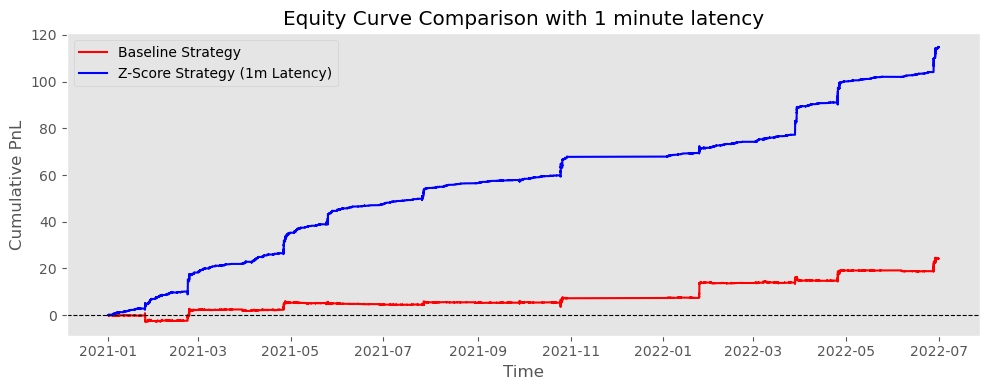

In [50]:
# Equity Curve Comparison

plt.figure(figsize=(10, 4))

plt.plot(equity_curves.index, equity_curves["Baseline Strategy"], label="Baseline Strategy", color="red")
plt.plot(equity_curves.index, equity_curves["Z-Score Strategy (1m Latency)"], label="Z-Score Strategy (1m Latency)", color="blue")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.title("Equity Curve Comparison with 1 minute latency")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

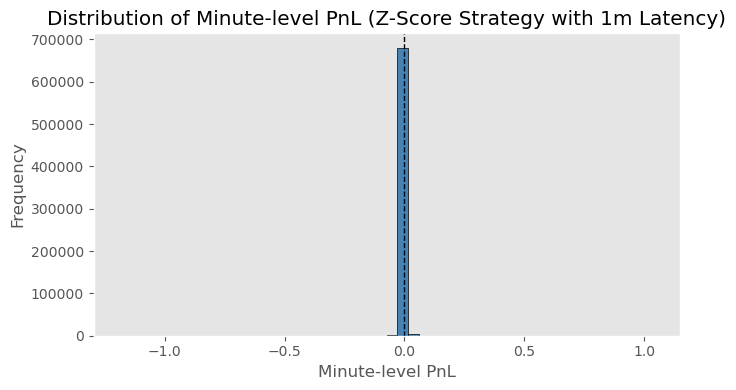

In [49]:
# Distribution of Minute-level PnL (Z-Score Strategy with 1m Latency)

plt.figure(figsize=(7, 4))

df["pnl_z_latency"].dropna().hist(bins=50, color="steelblue", edgecolor="black")

# Zero-profit reference line
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Minute-level PnL")
plt.ylabel("Frequency")
plt.title("Distribution of Minute-level PnL (Z-Score Strategy with 1m Latency)")
plt.grid()
plt.tight_layout()
plt.show()

## **Return** in percentage

In [53]:
initial_capital = 100

# No latency
equity_baseline = initial_capital + df["pnl_baseline"].fillna(0).cumsum()
equity_zscore = initial_capital + df["pnl_z"].fillna(0).cumsum()

# With latency
equity_z_latency = initial_capital + df["pnl_z_latency"].fillna(0).cumsum()

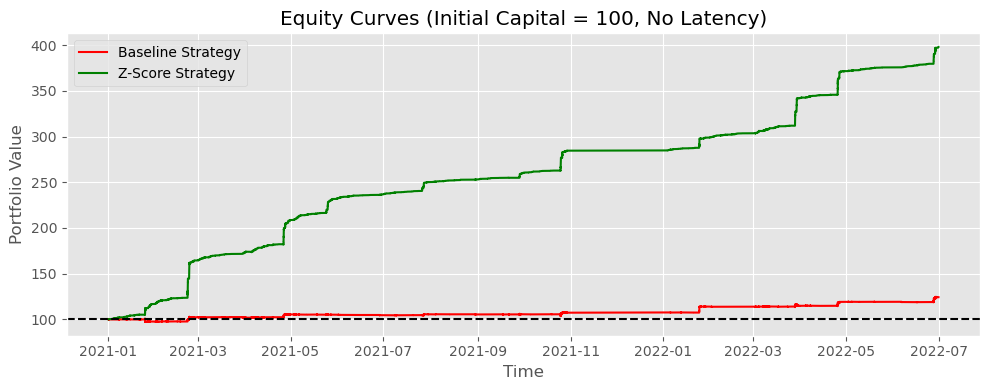

In [54]:
plt.figure(figsize=(10,4))

plt.plot(equity_baseline.index, equity_baseline, label="Baseline Strategy", color="red")
plt.plot(equity_zscore.index, equity_zscore, label="Z-Score Strategy", color="green")

plt.axhline(initial_capital, linestyle="--", color="black")

plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.title("Equity Curves (Initial Capital = 100, No Latency)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

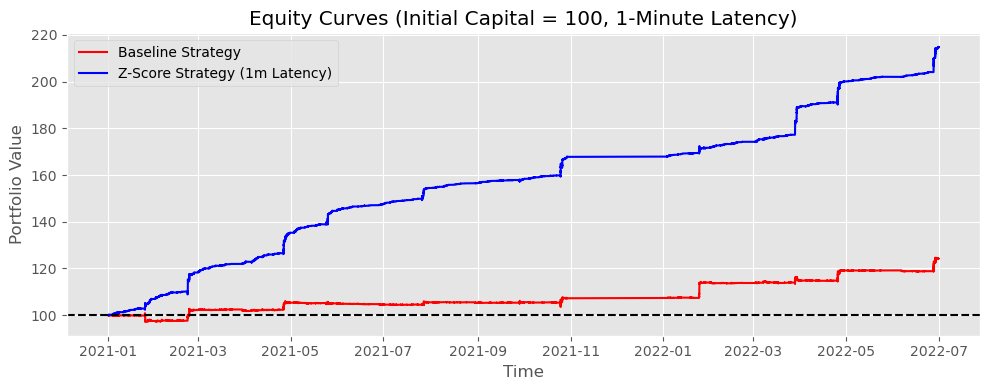

In [55]:
plt.figure(figsize=(10,4))

plt.plot(equity_baseline.index, equity_baseline, label="Baseline Strategy", color="red")
plt.plot(equity_z_latency.index, equity_z_latency, label="Z-Score Strategy (1m Latency)", color="blue")

plt.axhline(initial_capital, linestyle="--", color="black")

plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.title("Equity Curves (Initial Capital = 100, 1-Minute Latency)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Result

## **Without Execution Latency**

| Strategy                        | Total PnL  | Sharpe Ratio | Max Drawdown | Approx Trades |
| ------------------------------- | ---------- | ------------ | ------------ | ------------- |
| Baseline Spread Strategy        | 24.23      | 1.73         | -3.76        | 310           |
| Z-Score Mean Reversion Strategy | **297.95** | **4.35**     | **-0.98**    | 5413          |

Key observations:

* The **Z-Score strategy significantly outperforms the baseline strategy**.
* Total profit increases from **24 → ~298**, more than **12× improvement**.
* The **Sharpe ratio improves from 1.73 to 4.35**, indicating much better risk-adjusted returns.
* The **maximum drawdown is substantially lower**, suggesting more stable performance.
* The Z-Score strategy executes **more trades**, reflecting its mean-reversion trading behavior.

The equity curve also clearly shows that the **Z-Score strategy produces consistent growth over time**, whereas the baseline strategy generates relatively small profits.




### **With 1-Minute Latency**

| Strategy                      | Total PnL  | Sharpe Ratio | Max Drawdown | Approx Trades |
| ----------------------------- | ---------- | ------------ | ------------ | ------------- |
| Baseline Strategy             | 24.23      | 1.73         | -3.76        | 310           |
| Z-Score Strategy (1m Latency) | **114.76** | **5.07**     | -2.85        | 5400          |

Key observations:

* Profitability **decreases from ~298 to ~115** after introducing latency.
* This confirms that **execution delays reduce arbitrage efficiency**.
* Despite this reduction, the Z-Score strategy still **significantly outperforms the baseline strategy**.
* The Sharpe ratio remains strong, indicating **robust risk-adjusted performance even under execution delay**.

The equity curve under latency still demonstrates **steady growth**, though at a slower rate compared to the ideal no-latency scenario.